# Exploration

## Initializations

In [1]:
# Remove the hash sign from the line below and run the cell to install the package for plotting
# !pip install git+https://github.com/garrettj403/SciencePlots

In [ ]:
# Imports from
from process_engineering_toolkit.units import ureg, standardize_units, Q_
from process_engineering_toolkit.stream import Stream
from process_engineering_toolkit.reactors.pfr import PFR
from process_engineering_toolkit.rate_laws import MassActionRateLaw, PowerLawRateLaw
from process_engineering_toolkit.reactions import Reactions

# Plotting
import matplotlib.pyplot as plt
import scienceplots
from process_engineering_toolkit.visualization.reactor_plotter import ReactorPlotter

## README clean

### Example: Single-reaction system (PFR)

This example demonstrates how to define, reactions, streams, as well as plug flow reactor and how to simulate.

In [3]:
# Define units
Pa = ureg.Pa
atm = ureg.atm
mol = ureg.mole
J = ureg.joule
K = ureg.kelvin
L = ureg.liter
s = ureg.s
min = ureg.minute
dm = ureg.decimeter
m = ureg.meter

In [ ]:
# -----------------------------
# 1. Define reactions
# -----------------------------

# Currently, two options are available.
# 1) Don't specify units: In this case the toolkit computes everything as is - The user will have to ensure unit consistency.
# 2) Specify units: The toolkit will convert to SI units internally, but the user can work with more intuitive units.
# Note: If using option 2, the user currently still has to provide rate constants/parameters in SI units. 
# The function standardize_units, which converts to desired units (and then strips them),
# can be used as below. 
kf = 0.3 / min              # Forward rate constant
kb = 3 * L / min / mol      # Backward rate constant
kf = standardize_units(kf, 1 / s)           # Convert to SI units and strip units
kb = standardize_units(kb, m**3 / s / mol)  # Convert to SI units and strip units

reactions = [
    {"equation": "A <-> 2B", "rate_law": "mass_action", "parameters": {"kf": kf, "kb": kb}}
    ]

rxns = Reactions(reactions)

# -----------------------------
# 2. Define inlet stream
# -----------------------------
s1 = Stream("Inlet1", total_flow = 20 * mol / min, composition = {"A": 0.6, "I": 0.4}) # I: Inert

# -----------------------------
# 3. Define reactor conditions
# -----------------------------
parameters = {
    "phase": "gas",    # Only gas is supported so far
    "T": 340 * K,          # K
    "P": 2 * 101325 * Pa    # Pa
}

# -----------------------------
# 4. Instantiate reactor
# -----------------------------
pfr = PFR(rxns, inlet_streams=s1, parameters=parameters)

# -----------------------------
# 5. Key calculations
# -----------------------------

# Equilibrium conversion of A
Xeq = pfr.equilibrium_conversion("A")
print(f"{'Equilibrium conversion':<45}: {Xeq:.3f}")

# Solve reactor over volume range [0, 5] m3
pfr.solve(V_span=(0, 5))  # m3 - Must solve reactor before below calculations can be performed

# Conversion at specific volume
X = pfr.conversion_at_volume("A", 0.5)
print(f"{'Conversion at 0.5 m3':<45}: {X:.3f}")

# Required volume for target conversion
V_req = pfr.volume_for_conversion("A", 0.4)
print(f"{'Required PFR volume for 40% conversion, m3':<45}: {V_req:.3f}")

Equilibrium conversion                       : 0.576
Conversion at 0.5 m3                         : 0.351
Required PFR volume for 40% conversion, m3   : 0.632


In [ ]:


plotter = ReactorPlotter()

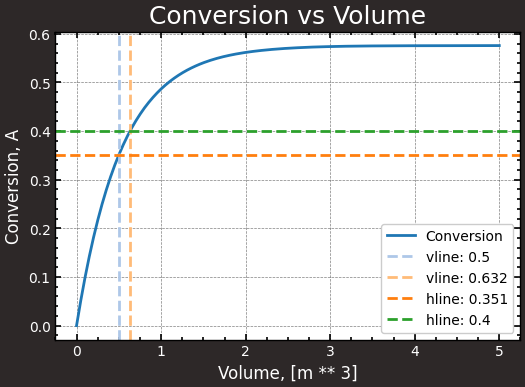

In [14]:
plotter.conversion_vs_volume(profile, "A", vlines=[0.5, V_req], hlines=[X, 0.4], legend_loc='best')

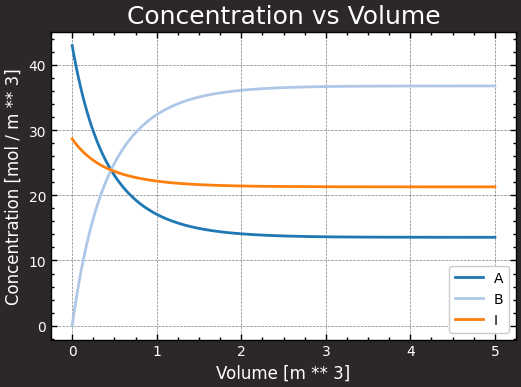

In [6]:
plotter.concentration_vs_volume(pfr)

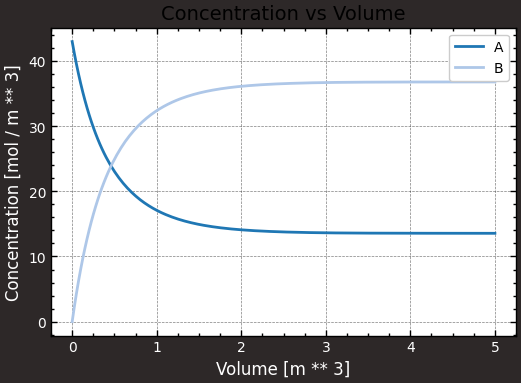

In [7]:
plotter.concentration_vs_volume(pfr, ["B", "A"])

In [7]:
plotter.concentration_vs_conversion(pfr)

TypeError: Expected Pint Quantity with units

In [ ]:
plotter.concentration_vs_volume(pfr, "A")

In [ ]:
plotter.conversion_vs_volume(pfr)

In [7]:
import matplotlib
matplotlib.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'bright',
 'cjk-jp-font',
 'cjk-kr-font',
 'cjk-sc-font',
 'cjk-tc-font',
 'classic',
 'dark_background',
 'discrete-rainbow-1',
 'discrete-rainbow-10',
 'discrete-rainbow-11',
 'discrete-rainbow-12',
 'discrete-rainbow-13',
 'discrete-rainbow-14',
 'discrete-rainbow-15',
 'discrete-rainbow-16',
 'discrete-rainbow-17',
 'discrete-rainbow-18',
 'discrete-rainbow-19',
 'discrete-rainbow-2',
 'discrete-rainbow-20',
 'discrete-rainbow-21',
 'discrete-rainbow-22',
 'discrete-rainbow-23',
 'discrete-rainbow-3',
 'discrete-rainbow-4',
 'discrete-rainbow-5',
 'discrete-rainbow-6',
 'discrete-rainbow-7',
 'discrete-rainbow-8',
 'discrete-rainbow-9',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'grid',
 'high-contrast',
 'high-vis',
 'ieee',
 'latex-sans',
 'light',
 'muted',
 'nature',
 'no-latex',
 'notebook',
 'petroff10',
 'pgf',
 'retro',
 'russian-font',
 'sans',
 'scatter',
 'science',


In [ ]:
plt.style.use(['science', 'notebook', 'grid'])

plt.rcParams['figure.facecolor'] = "#2D2828"   # outside plot
# plt.rcParams['axes.facecolor'] = "#A8C0CA"     # inside plot (optional override)
plt.rcParams['savefig.facecolor'] = '#2E2E2E'  # saved figures
# plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
# plt.rcParams['axes.edgecolor'] = "black"

# Default figure size
plt.rcParams['figure.figsize'] = (6, 4)  # 6 inch width, 4 inch height
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6

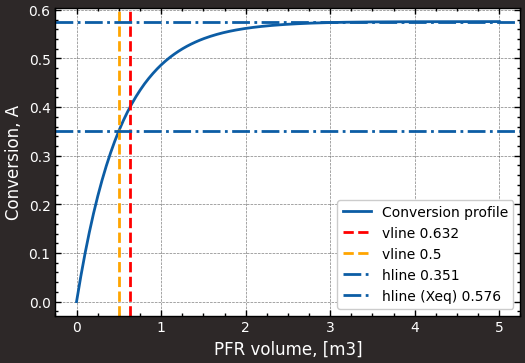

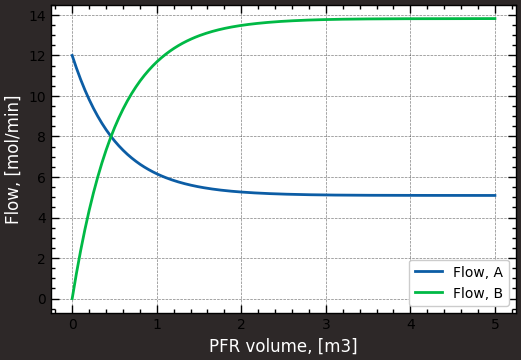

In [9]:
fig, ax = plt.subplots()

# Plot 1
ax.plot(volume, conversion, label="Conversion profile")

# Vertical lines
ax.axvline(x=V_req, color='red', linestyle='--', label=f'vline {V_req:.3f}')
ax.axvline(x=0.5, color='orange', linestyle='--', label='vline 0.5')

# Horizontal lines
ax.axhline(y=X, linestyle='-.', label=f'hline {X:.3f}')
ax.axhline(y=Xeq, linestyle='-.', label=f'hline (Xeq) {Xeq:.3f}')

# Labels and legend
ax.set_xlabel("PFR volume, [m3]")
ax.set_ylabel("Conversion, A")
ax.legend(loc='lower right')

# 👇 STYLE BLOCK (this is the right place)

# Turn on minor ticks
ax.minorticks_on()

# Control how many minor ticks (optional but recommended)
from matplotlib.ticker import AutoMinorLocator
ax.xaxis.set_minor_locator(AutoMinorLocator(4))  # only x-axis
ax.yaxis.set_minor_locator(AutoMinorLocator(5))  # only y-axis

# Major ticks
ax.tick_params(axis='both', which='major', length=4, width=1, colors='black')

# Minor ticks
ax.tick_params(axis='both', which='minor', length=2, width=1, colors='black')

# Tick labels
ax.tick_params(axis='both', labelcolor='white')

plt.show()

# Plot 2
plt.plot(volume, flow_a, label="Flow, A")
plt.plot(volume, flow_b, label="Flow, B")
plt.xlabel("PFR volume, [m3]")
plt.ylabel("Flow, [mol/min]")
plt.legend(loc='lower right')
plt.show()

### Example: Multi-reaction system (PFR)

This example demonstrates how to define and simulate a plug flow reactor with:
- multiple simultaneous reactions
- different kinetic models (mass-action and custom power-law)
- multiple inlet streams

In [34]:
from pint import UnitRegistry

ureg = UnitRegistry()
Q_ = ureg.Quantity

v0 = 1 * ureg.m ** 3 / ureg.s

print(v0)

1.0 meter ** 3 / second


Equilibrium conversion                       : 0.633
Conversion at 0.5 m3                         : 0.278
Required PFR volume for 40% conversion, m3   : 0.861


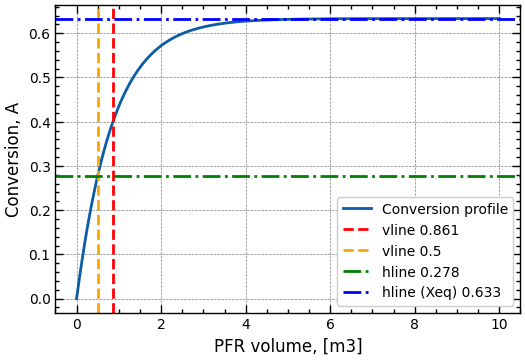

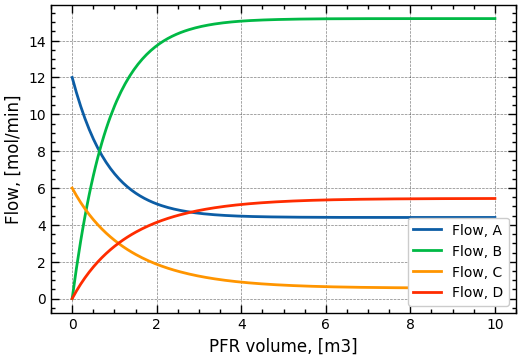

In [ ]:
# -----------------------------
# 1. Define reactions
# -----------------------------

# Custom power-law expression for C <-> 2D
power_expr = "kf * C - kb * D^2"

reactions = [
    {"equation": "A <-> 2B", "rate_law": "mass_action",  "parameters": {"kf": 0.3, "kb": 0.003}},
    {"equation": "C <-> D", "rate_law": "power",         "parameters": {"expression": power_expr, "kf": 0.3, "kb": 0.003}}
    ]

rxns = Reactions(reactions)

# -----------------------------
# 2. Define inlet stream
# -----------------------------
# Two independent feeds containing different reactants
s1 = Stream("Inlet1", total_flow=20, composition={"A": 0.6, "I": 0.4}) # I = inert
s2 = Stream("Inlet2", total_flow=10, composition={"C": 0.6, "I": 0.4}) # I = inert

# -----------------------------
# 3. Define reactor conditions
# -----------------------------
parameters = {
    "phase": "gas",    # Only gas is supported so far
    "T": 340,          # K
    "P": 2 * 101325    # Pa
}

# -----------------------------
# 4. Instantiate reactor
# -----------------------------
pfr = PFR(rxns, inlet_streams=[s1, s2], parameters=parameters)

# -----------------------------
# 5. Key calculations
# -----------------------------

# Equilibrium conversion of A
Xeq = pfr.equilibrium_conversion("A")
print(f"{'Equilibrium conversion':<45}: {Xeq:.3f}")

# Solve reactor over volume range [0, 10] m3
pfr.solve(V_span=(0, 10))  # m3 - Must solve reactor before below calculations can be performed

# Conversion at specific volume
X = pfr.conversion_at_volume("A", 0.5)
print(f"{'Conversion at 0.5 m3':<45}: {X:.3f}")

# Required volume for target conversion
V_req = pfr.volume_for_conversion("A", 0.4)
print(f"{'Required PFR volume for 40% conversion, m3':<45}: {V_req:.3f}")

# Extract profiles
profile = pfr.profile("A")

# All of the plotting needs to be adjusted to the new reaction system
plt.plot(profile["volume"], profile["conversion"], label="Conversion profile")
# Add vertical lines
plt.axvline(x=V_req, color='red', linestyle='--', label=f'vline {V_req:.3f}')
plt.axvline(x=0.5, color='orange', linestyle='--', label='vline 0.5')
# Add horizontal line
plt.axhline(y=X, color='green', linestyle='-.', label=f'hline {X:.3f}')
plt.axhline(y=Xeq, color='blue', linestyle='-.', label=f'hline (Xeq) {Xeq:.3f}')
# Labels and legend
plt.xlabel("PFR volume, [m3]")
plt.ylabel("Conversion, A")
plt.legend(loc='lower right')
plt.show()

plt.plot(profile["volume"], profile["flow"]["A"], label="Flow, A")
plt.plot(profile["volume"], profile["flow"]["B"], label="Flow, B")
plt.plot(profile["volume"], profile["flow"]["C"], label="Flow, C")
plt.plot(profile["volume"], profile["flow"]["D"], label="Flow, D")
plt.xlabel("PFR volume, [m3]")
plt.ylabel("Flow, [mol/min]")
plt.legend(loc='lower right')
plt.show()

## Mass Action vs Power Law testing

### Setup

In [ ]:
import numpy as np
from process_engineering_toolkit.reactions import Reaction
from process_engineering_toolkit.rate_laws import MassActionRateLaw, PowerLawRateLaw

# Species
species_list = ["A", "B", "C"]
species_index = {s: i for i, s in enumerate(species_list)}

# Stoichiometry
stoichiometry = {
    "A": -1,
    "B": -1,
    "C": 1
}

# Concentrations (mol/L)
C = np.array([2.0, 1.5, 0.0])
T = 350  # K

Mass action rate: 1.5
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


### Rate determination: Irreversibel reaction

In [13]:
# Mass Action (elementary reaction)
params_mass_action = {
    "kf": 0.5
}

ma = MassActionRateLaw(stoichiometry, **params_mass_action)

rxn = Reaction("R1", stoichiometry, ma)
rxn._compile(species_index)

print("Mass action rate:", rxn.rate(C, T))
print(f"species_list: {species_list}")
print(f"species_index: {species_index}")

Mass action rate: 1.5
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


In [14]:
# Power Law
params_power_law = {
    "expression": "A * B",
    "kf": 0.5
}

pl = PowerLawRateLaw(stoichiometry, **params_power_law)

rxn = Reaction("R1", stoichiometry, pl)
rxn._compile(species_index)

print("Power law rate:", rxn.rate(C, T))
print(f"species_list: {species_list}")
print(f"species_index: {species_index}")

Power law rate: 1.5
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


### Rate determination: Reversible reaction

In [15]:
C = np.array([2.0, 1.5, 0.5])
T = 350

In [16]:
# Mass Action (elementary reaction)
params_mass_action = {
    "kf": 0.5,
    "kb": 0.1,
}

ma = MassActionRateLaw(stoichiometry, **params_mass_action)

rxn = Reaction("R1", stoichiometry, ma)
rxn._compile(species_index)

print("Mass action rate:", rxn.rate(C, T))
print(f"species_list: {species_list}")
print(f"species_index: {species_index}")

Mass action rate: 1.45
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


In [19]:
# Power law
params_mass_action = {
    "expression": "A * B - C",
    "kf": 0.5,
    "kb": 0.1,
}

pl = PowerLawRateLaw(stoichiometry, **params_mass_action)

rxn = Reaction("R1", stoichiometry, pl)
rxn._compile(species_index)

print("Power Law rate:", rxn.rate(C, T))
print(f"species_list: {species_list}")
print(f"species_index: {species_index}")

Power Law rate: 1.45
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


### Non-integer orders (Power Law only)

In [25]:
params_power_law = {
    "expression": "A^0.5 * B^1.2 - C^1.5",
    "kf": 0.5,
    "kb": 0.1,
}

pl = PowerLawRateLaw(stoichiometry, **params_power_law)

rxn = Reaction("R1", stoichiometry, pl)
rxn._compile(species_index)

print("Power Law rate:", rxn.rate(C, T))
print(f"species_list: {species_list}")
print(f"species_index: {species_index}")

Power Law rate: 1.1149006760695908
species_list: ['A', 'B', 'C']
species_index: {'A': 0, 'B': 1, 'C': 2}


In [26]:
print(0.5*C[0]**(0.5)*C[1]**(1.2) - 0.1*C[2]**1.5)

1.1149006760695908


### Arrhenius test

In [ ]:
params_mass_action = {
    "k0_f": 1e3,
    "Ea_f": 50000  # J/mol
}

ma = MassActionRateLaw(stoichiometry, species_list, **params_mass_action)

print("Mass action Arrhenius rate:", ma.rate(C, T))

Mass action Arrhenius rate: 3.448570123742299e-05


In [10]:
for T in [300, 350, 400]:
    print(T, ma.rate(C, T))

300 5.902465985837268e-06
350 0.00010345710371226898
400 0.0008862483374188033


In [11]:
params_power_law = {
    "expression": "A * B",
    "k0_f": 1e3,
    "Ea_f": 50000  # J/mol
}

pl = PowerLawRateLaw(stoichiometry, species_list, **params_power_law)

print("Power law Arrhenius rate:", pl.rate(C, 350))

Power law Arrhenius rate: 0.00010345710371226898


In [12]:
for T in [300, 350, 400]:
    print(T, pl.rate(C, T))

300 5.902465985837268e-06
350 0.00010345710371226898
400 0.0008862483374188033


### Edge cases: Invalid usage

In [13]:
PowerLawRateLaw(
    stoichiometry,
    species_list,
    expression="A * B",
    kb=0.1  # ← should trigger validation
)

ValueError: Backward rate constants provided but expression has no backward term

In [14]:
PowerLawRateLaw(
    stoichiometry,
    species_list,
    expression="A * D",  # D not in species_list
    kf=1.0
)

ValueError: Unknown species in rate expression: D

In [23]:
PowerLawRateLaw(
    stoichiometry,
    species_list,
    expression="a**(1/2) * B",  # Invalid math symbol (for simplicity, division symbol not allowed)
    kf=1.0
)

ValueError: Invalid exponent in factor a^(1/2)

## Stream definition

In [ ]:
# # This will raise an error as mole fractions must be non-negative
# s1 = Stream("Fresh A", 10, {"A": -1, "B": 0.5}) 
# s2 = Stream("Co-feed", 5, {"B": 0.6, "C": 0.4})

# print(s1.flows)
# print(s2.flows)

# # This will raise an error as compositions must sum to 1
# s1 = Stream("Fresh A", 10, {"A": 0.7, "B": 0.2}) 
# s2 = Stream("Co-feed", 5, {"B": 0.6, "C": 0.4})

# print(s1.flows)
# print(s2.flows)

# inlet = Flow([s1, s2])
# print(inlet.total_flows())

# s1 = Stream("Fresh A", 10, {"A": 0.8, "B": 0.2})
# s2 = Stream("Co-feed", 5, {"B": 0.6, "C": 0.4})

# print(s1.flows)
# print(s2.flows)